# Multi-Class Classification: MNIST Digit Recognition

This notebook demonstrates a deep neural network training on the full MNIST dataset.
We will utilize advanced features like **Batch Normalization** and **Dropout** to achieve high accuracy.

In [1]:
import matplotlib.pyplot as plt
from diy_neural_net import NeuralNetwork, utils
from diy_neural_net.Layers import Dense, Dropout, BatchNorm
from diy_neural_net.Activations import ReLU
from diy_neural_net.Losses import CrossEntropyLossWithLogits
from diy_neural_net.Optimizer import Adam
from diy_neural_net.DeviceSelector import get_numpy, is_gpu_available

np = get_numpy()
print(f"Hardware Acceleration: {'GPU (CuPy)' if is_gpu_available() else 'CPU (NumPy)'}")

Using GPU
Hardware Acceleration: GPU (CuPy)


## 1. Load MNIST Data

In [2]:
X, y = utils.load_mnist()
X_train, X_test, y_train, y_test = utils.train_test_split(X, y, test_size=0.15)

n_classes = y.shape[0]
n_features = X.shape[0]

print(f"Classes: {n_classes}")
print(f"Features per image: {n_features}")
print(f"Training samples: {X_train.shape[1]}")

Loading data from: ../Data/train.csv
Classes: 10
Features per image: 784
Training samples: 35700


## 2. Deep Network Architecture
We construct a deep network using the `Sequential` API.

**Architecture Strategy:**
- **Dense Layers** with He Initialization for ReLU.
- **BatchNorm** after Dense layers to stabilize learning and allow higher learning rates.
- **Dropout** to prevent overfitting in the deeper layers.
- **Output Layer**: Linear output (logits), because we are using `CrossEntropyLossWithLogits`.

In [3]:
dropout_rate = 0.85 # Keep probability

model = NeuralNetwork.Sequential([
    # Input Block
    Dense(n_features, 512, initializer="he"),
    BatchNorm(512),
    ReLU(),
    
    # Hidden Block 1
    Dense(512, 256, initializer="he"),
    BatchNorm(256),
    ReLU(),
    Dropout(keep_prob=dropout_rate),
    
    # Hidden Block 2
    Dense(256, 128, initializer="he"),
    BatchNorm(128),
    ReLU(),
    Dropout(keep_prob=dropout_rate),

    # Output Block
    Dense(128, n_classes, initializer="glorot") 
    # No Softmax here! It's integrated into the Loss function for stability.
])

model.set_loss(CrossEntropyLossWithLogits())

## 3. Training with Adam
We train for 30 epochs using a larger batch size for GPU efficiency.

In [4]:
optimizer = Adam(model, lr=0.001)

history = model.fit(
    X_train=X_train,
    y_train=y_train,
    optimizer=optimizer,
    batch_size=256, 
    epochs=30,
    shuffle=True,
    validation_data=(X_test, y_test),
    early_stopping_patience=5
)

Epoch : 0
Train Loss : 2.3155 Test Loss : 0.5396
Epoch : 10
Train Loss : 0.2054 Test Loss : 0.1860
Epoch : 20
Train Loss : 0.1144 Test Loss : 0.2096
Early stopping triggered during epoch : 23
best val_loss = 0.1113


## 4. Results

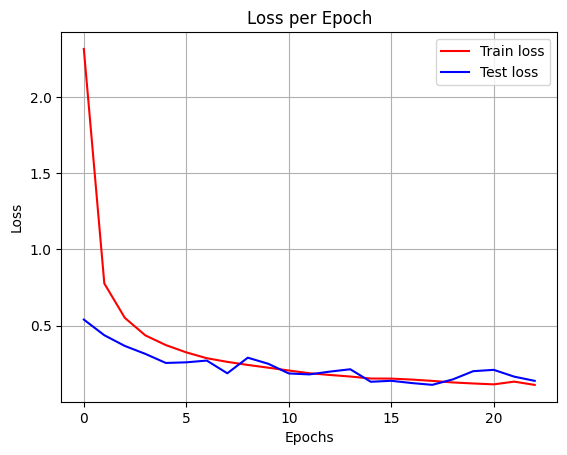

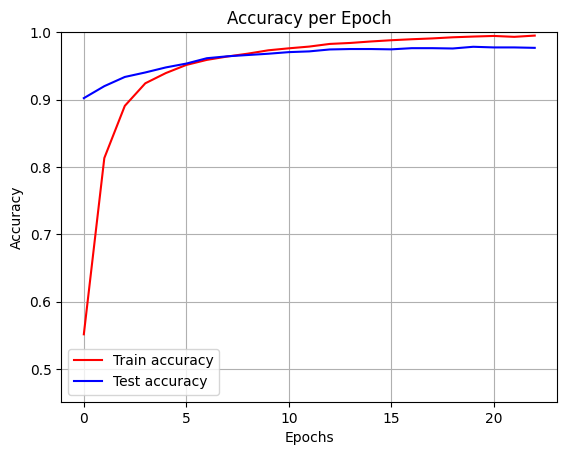


Final Test Accuracy: 97.67%


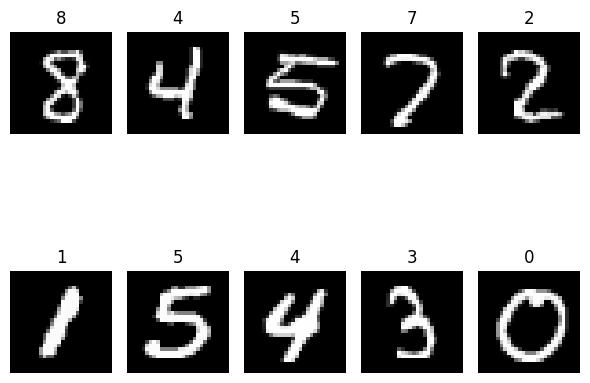

In [5]:
utils.plot_metrics(history)

test_preds = model.predict(X_test)
acc = model.accuracy_score(test_preds, y_test)
print(f"\nFinal Test Accuracy: {acc*100:.2f}%")

# Visualize classifications
utils.plot_image(X_test, model, n_images=10, n_classes=10)